In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import svm 


In [2]:
loan_data=pd.read_csv("C:/mldataset/loan_status_data.csv")

In [3]:
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
loan_data.shape

(614, 13)

In [9]:
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
loan_data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
#droping missing value
loan_data=loan_data.dropna()

In [15]:
loan_data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [17]:
#label encoding 
loan_data.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)

C:\Users\anjit\AppData\Local\Temp\ipykernel_25948\3419423902.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)
C:\Users\anjit\AppData\Local\Temp\ipykernel_25948\3419423902.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)


In [19]:
loan_data['Dependents'].value_counts()

Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64

In [21]:
#replacing 3+ values to 4
loan_data=loan_data.replace(to_replace='3+',value=4)

In [23]:
loan_data['Dependents'].value_counts()

Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64

<Axes: xlabel='Education', ylabel='count'>

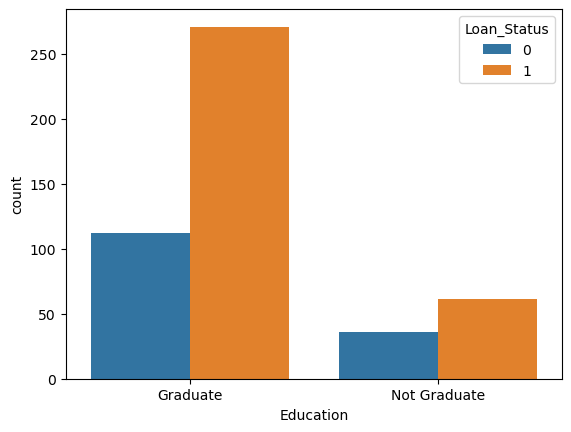

In [25]:
#data visualization 
#education vs loan status
sns.countplot(x='Education',hue="Loan_Status",data=loan_data,legend=True)

C:\Users\anjit\AppData\Local\Temp\ipykernel_25948\1319590623.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.countplot(x='Married',hue="Loan_Status",data=loan_data,legend=True,color="green")


<Axes: xlabel='Married', ylabel='count'>

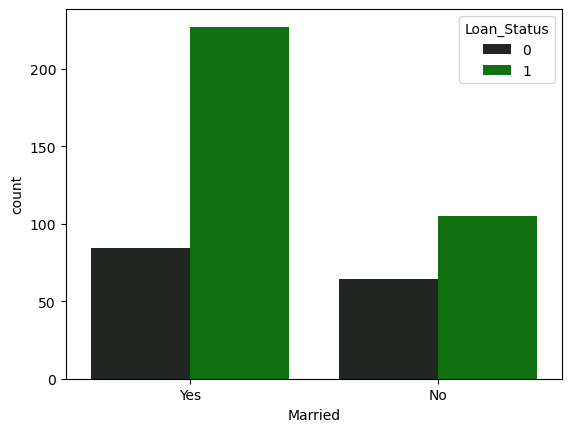

In [27]:
sns.countplot(x='Married',hue="Loan_Status",data=loan_data,legend=True,color="green")

<Axes: xlabel='Gender', ylabel='count'>

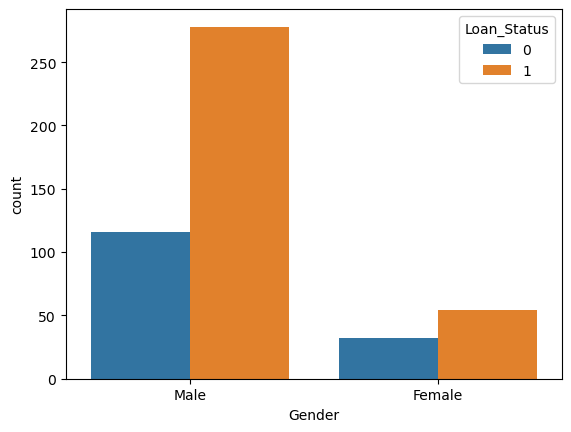

In [29]:
sns.countplot(x='Gender',hue='Loan_Status',data=loan_data)

In [31]:
#converting data into label encoding 
#label encoding 
loan_data.replace({"Married":{'No':0,'Yes':1}},inplace=True)

C:\Users\anjit\AppData\Local\Temp\ipykernel_25948\32742995.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data.replace({"Married":{'No':0,'Yes':1}},inplace=True)


In [33]:
#label encoding 
loan_data.replace({"Gender":{"Female":0,"Male":1}},inplace=True)

C:\Users\anjit\AppData\Local\Temp\ipykernel_25948\456581045.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data.replace({"Gender":{"Female":0,"Male":1}},inplace=True)


In [35]:
loan_data.replace({"Self_Employed":{'No':0,'Yes':1}},inplace=True)

C:\Users\anjit\AppData\Local\Temp\ipykernel_25948\800273882.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data.replace({"Self_Employed":{'No':0,'Yes':1}},inplace=True)


In [37]:
loan_data.replace({'Education':{'Not Graduate':0,"Graduate":1}},inplace=True)

C:\Users\anjit\AppData\Local\Temp\ipykernel_25948\1958406916.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data.replace({'Education':{'Not Graduate':0,"Graduate":1}},inplace=True)


In [39]:
loan_data.replace({"Property_Area":{"Rural":0,"Semiurban":1,"Urban":2}},inplace=True)

C:\Users\anjit\AppData\Local\Temp\ipykernel_25948\1875306302.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data.replace({"Property_Area":{"Rural":0,"Semiurban":1,"Urban":2}},inplace=True)


In [41]:
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [43]:
X=loan_data.drop(columns=['Loan_Status','Loan_ID'],axis=1)
print(X)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
1         1        1          1          1              0             4583   
2         1        1          0          1              1             3000   
3         1        1          0          0              0             2583   
4         1        0          0          1              0             6000   
5         1        1          2          1              1             5417   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          1              0             2900   
610       1        1          4          1              0             4106   
611       1        1          1          1              0             8072   
612       1        1          2          1              0             7583   
613       0        0          0          1              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

In [45]:
Y=loan_data['Loan_Status']
print(Y)

1      0
2      1
3      1
4      1
5      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 480, dtype: int64


In [124]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,stratify=Y,random_state=2)

In [126]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((432, 11), (48, 11), (432,), (48,))

In [49]:
classifier=svm.SVC(kernel="linear")

In [51]:
#training support vector machine model
classifier.fit(X_train,Y_train)

SVC(kernel='linear')

In [53]:
#accuracy score of training data 
x_train_prediction=classifier.predict(X_train)
training_data_accuracy=accuracy_score(x_train_prediction,Y_train)
print("Accuracy of training data:",training_data_accuracy)

Accuracy of training data: 0.7986111111111112


In [55]:
x_test_prediction=classifier.predict(X_test)
testing_data_accuracy=accuracy_score(x_test_prediction,Y_test)
print("Accuracy of testing data:",testing_data_accuracy)

Accuracy of testing data: 0.8333333333333334


In [145]:
gender_mapping = {'Male':1, 'Female':0}

married_mapping = {'Yes':1, 'No':0}

education_mapping = {'Graduate':1, 'Not Graduate':0}

self_employed_mapping = {'Yes':1, 'No':0}

property_area_mapping = {'Rural':0, 'Semiurban':1, 'Urban':2}

input_data = ('Male','Yes',0,'Not Graduate','No',7660,0,104,360,0,'Urban')

converted_data = (
    gender_mapping[input_data[0]],
    married_mapping[input_data[1]],
    input_data[2],
    education_mapping[input_data[3]],
    self_employed_mapping[input_data[4]],
    input_data[5],
    input_data[6],
    input_data[7],
    input_data[8],
    input_data[9],
    property_area_mapping[input_data[10]]
)

input_data_as_array = np.asarray(converted_data)

input_data_reshaped = input_data_as_array.reshape(1,-1)

prediction = classifier.predict(input_data_reshaped)
print(prediction)

if(prediction[0] == 1):
    print("Loan Approved")
else:
    print("Loan Not Approved")

[0]
Loan Not Approved


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [149]:
input_data =  (1, 1, 0, 1, 0, 5849, 0, 128, 360, 1, 2)


input_data_as_array = np.asarray(input_data)

input_data_reshaped = input_data_as_array.reshape(1,-1)

prediction = classifier.predict(input_data_reshaped)

print(prediction)

if(prediction[0] == 1):
    print('Loan Approved')
else:
    print('Loan Not Approved')

[1]
Loan Approved


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
